# DAML Assignment 1 - WERKCOL 3-5 

The notebook tells the story of how we approached the problem: Predict `score` for the 79 students in `test.rds` using the 316 students in `train.rds`. The key metric for evaluation is mean squared error (MSE).

**Storyline**

| Part | Executive summary |
|---|---|
| 1. Exploratory data analysis | What does the data look like, and which variables carry signal? |
| 2. Data preprocessing | How do we turn the raw columns into model-ready features without leaking information? |
| 3. Theoretical framework | Which model families do we use, and what does each one assume? |
| 4. Model tuning and comparison | Which hyper-parameters are best *within* a framework, and which framework is best *across* frameworks? |
| 5. Final model and predictions | Which model is the final champion, and what are its predictions? |

Every number used for a decision comes from cross-validation on the training data. The test set is touched exactly once, in Part 5.

In [89]:
import warnings, time, shutil, subprocess, tempfile, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import pyreadr
from scipy import stats

from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import (GridSearchCV, KFold, RepeatedKFold, cross_validate,
                                     cross_val_predict, learning_curve)
from sklearn.metrics import mean_squared_error

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
SEED = 42

train = pyreadr.read_r("train.rds")[None]
test = pyreadr.read_r("test.rds")[None]
X_raw = train.drop(columns="score")
y = train["score"].to_numpy()
n = len(train)
print("train:", train.shape, "| test:", test.shape, "| missing values:", int(train.isna().sum().sum()), int(test.isna().sum().sum()))
train.head()

train: (316, 31) | test: (79, 30) | missing values: 0 0


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,score
0,GP,F,18.0,U,GT3,T,3.0,2.0,other,services,...,yes,yes,5.0,4.0,3.0,2.0,3.0,1.0,7.0,0.648402
1,GP,F,17.0,U,GT3,T,3.0,4.0,services,other,...,yes,no,4.0,4.0,5.0,1.0,3.0,5.0,16.0,1.169019
2,GP,M,17.0,U,GT3,T,2.0,3.0,other,other,...,yes,no,5.0,2.0,2.0,1.0,1.0,2.0,4.0,0.384039
3,GP,M,18.0,R,GT3,T,4.0,3.0,teacher,services,...,yes,yes,5.0,3.0,2.0,1.0,2.0,4.0,9.0,1.207493
4,GP,F,16.0,U,GT3,T,1.0,3.0,at_home,services,...,yes,yes,4.0,3.0,5.0,1.0,1.0,3.0,0.0,-1.215206


---
# 1. Exploratory data analysis

First, we try to understand the dataset. The section includes:
- Exploratory data analysis on the target variable, 
- Relations to the predictors, and 
- Relations between predictors and the target

## 1.1 On target variable

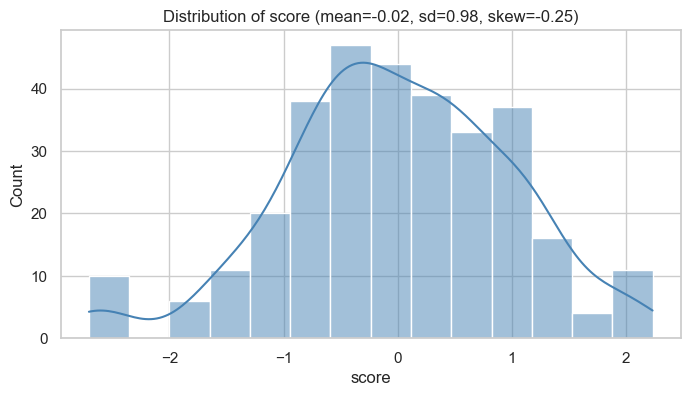

Variance of score: 0.97


In [90]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(train["score"], kde=True, ax=ax, color="steelblue")
ax.set_title(f"Distribution of score (mean={y.mean():.2f}, sd={y.std():.2f}, skew={stats.skew(y):.2f})")
plt.show()
print("Variance of score:", round(y.var(), 3))

`score` looks standardised and roughly symmetric, so no target transformation is needed. The MSE of the "always predict the mean" baseline equals the variance of `score` (about 0.97). 

## 1.2 Numeric predictors: are the relations linear?

Red line = LOWESS smoother. A straight red line means a linear relation.

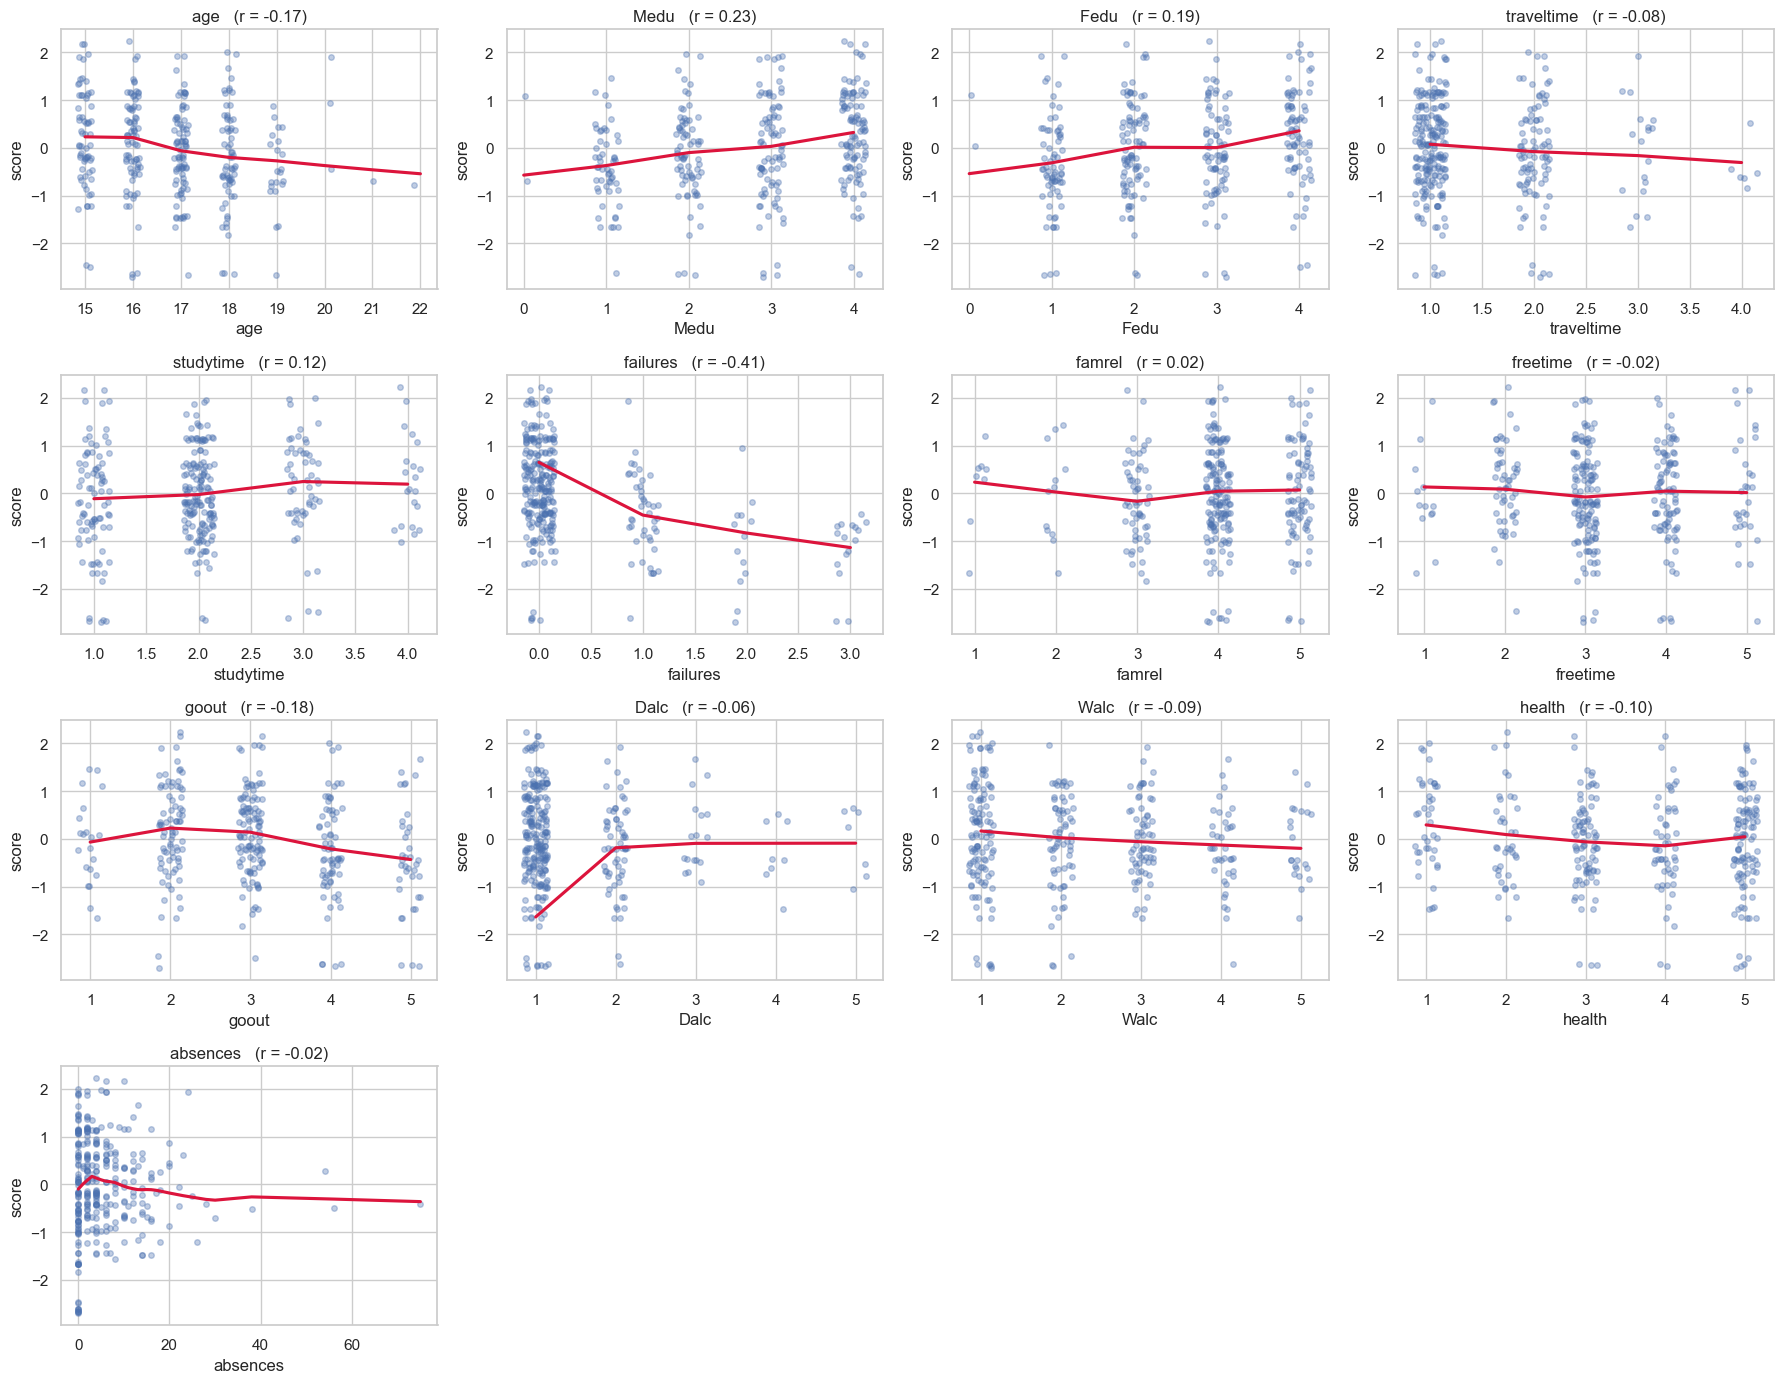

In [91]:
num_cols = X_raw.select_dtypes("number").columns.tolist()
fig, axes = plt.subplots(4, 4, figsize=(18, 14)); axes = axes.ravel()
for ax, c in zip(axes, num_cols):
    sns.regplot(data=train, x=c, y="score", lowess=True, x_jitter=0.15 if train[c].nunique() <= 20 else 0,
                scatter_kws=dict(alpha=.35, s=16), line_kws=dict(color="crimson"), ax=ax)
    ax.set_title(f"{c}   (r = {train[c].corr(train['score']):.2f})")
for ax in axes[len(num_cols):]: ax.axis("off")
plt.tight_layout(); plt.show()

## 1.3 Categorical predictors

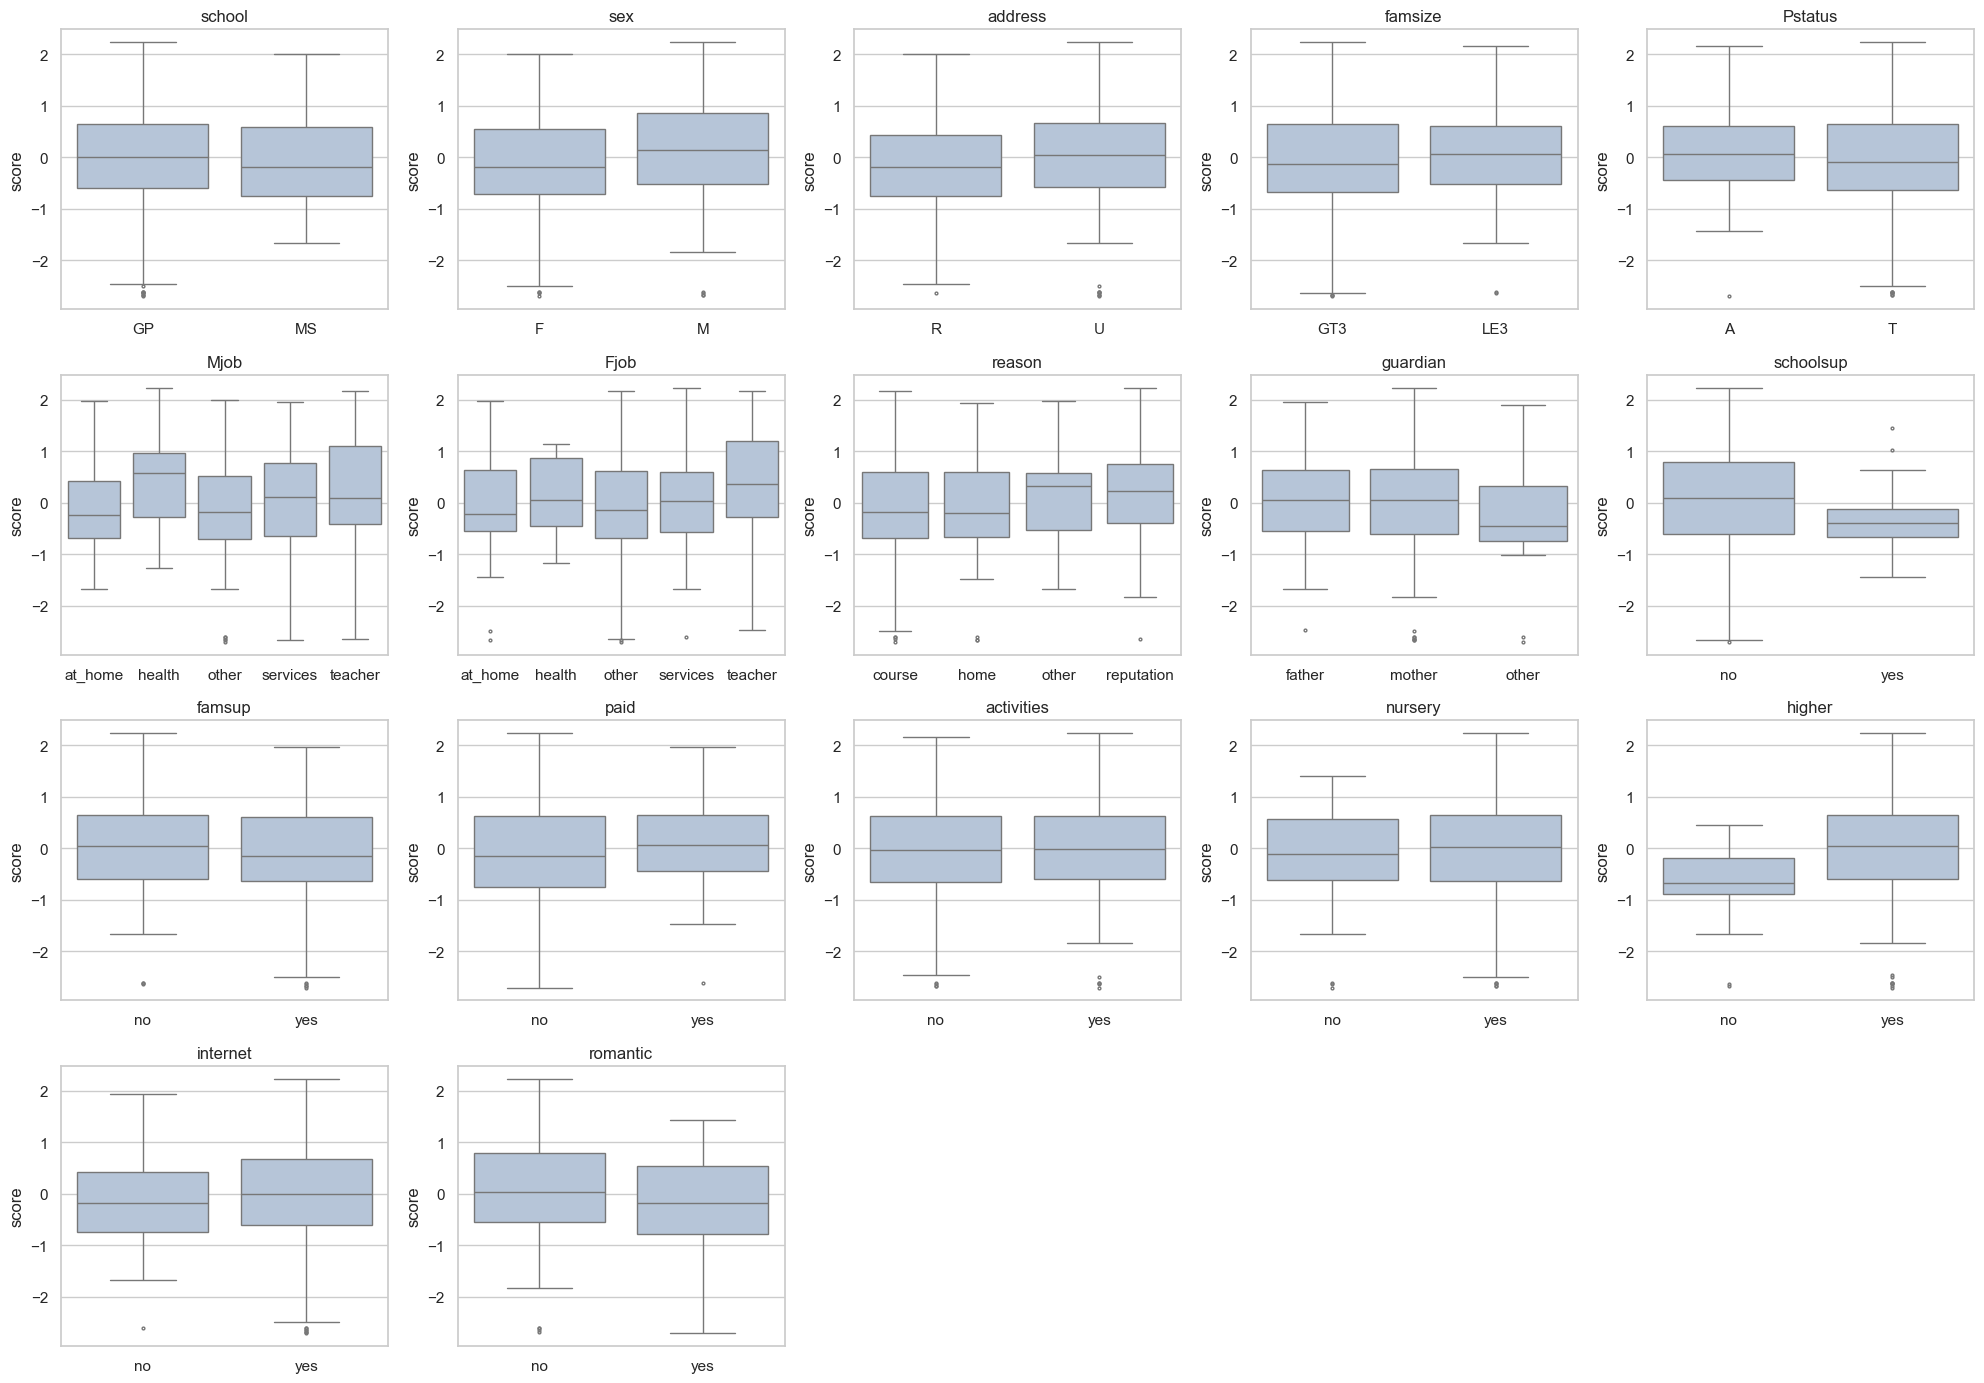

In [92]:
cat_cols = X_raw.select_dtypes("category").columns.tolist()
fig, axes = plt.subplots(4, 5, figsize=(20, 14)); axes = axes.ravel()
for ax, c in zip(axes, cat_cols):
    sns.boxplot(data=train, x=c, y="score", ax=ax, color="lightsteelblue", fliersize=2)
    ax.set_title(c); ax.set_xlabel("")
for ax in axes[len(cat_cols):]: ax.axis("off")
plt.tight_layout(); plt.show()

## !! 1.4 Which variables matter on their own?

Univariate strength of association with `score`: R² (squared correlation) for numeric variables and η² (share of variance explained by group means) for categorical variables. Both are on the same 0 to 1 scale.

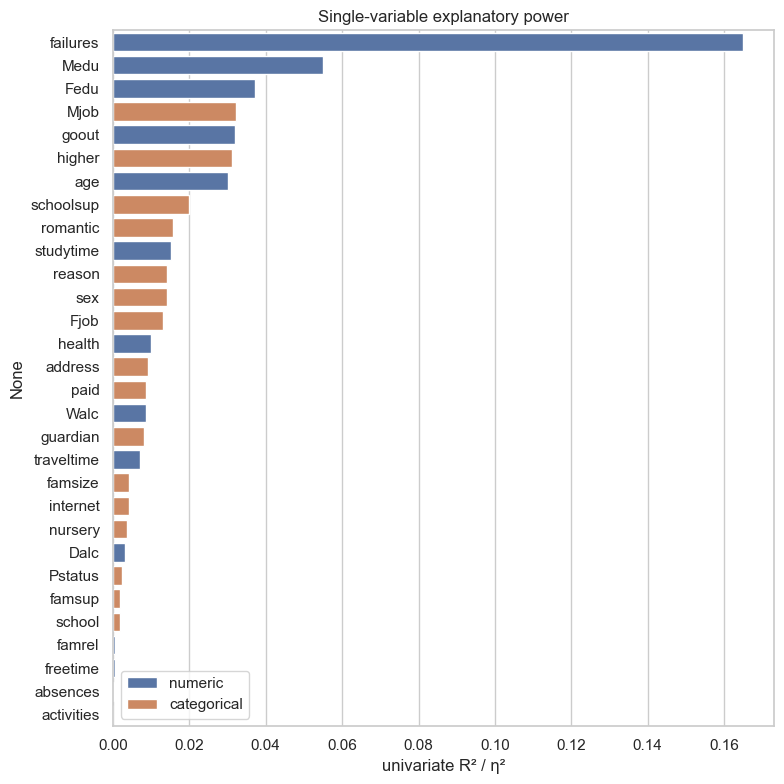

failures     0.165
Medu         0.055
Fedu         0.037
Mjob         0.032
goout        0.032
higher       0.031
age          0.030
schoolsup    0.020
Name: univariate_R2, dtype: float64

In [93]:
def eta_squared(x, yv):
    groups = [yv[(x == g).to_numpy()] for g in x.unique()]
    ss_between = sum(len(g) * (g.mean() - yv.mean()) ** 2 for g in groups)
    return ss_between / ((yv - yv.mean()) ** 2).sum()

uni = pd.Series({**{c: train[c].corr(train["score"]) ** 2 for c in num_cols},
                 **{c: eta_squared(train[c], y) for c in cat_cols}}, name="univariate_R2").sort_values(ascending=False)
kind = pd.Series({**{c: "numeric" for c in num_cols}, **{c: "categorical" for c in cat_cols}})

fig, ax = plt.subplots(figsize=(8, 8))
sns.barplot(x=uni.values, y=uni.index, hue=kind[uni.index].values, dodge=False, ax=ax)
ax.set_xlabel("univariate R² / η²"); ax.set_title("Single-variable explanatory power")
plt.tight_layout(); plt.show()
uni.head(8).round(3)

## 1.5 Correlation between numeric predictors

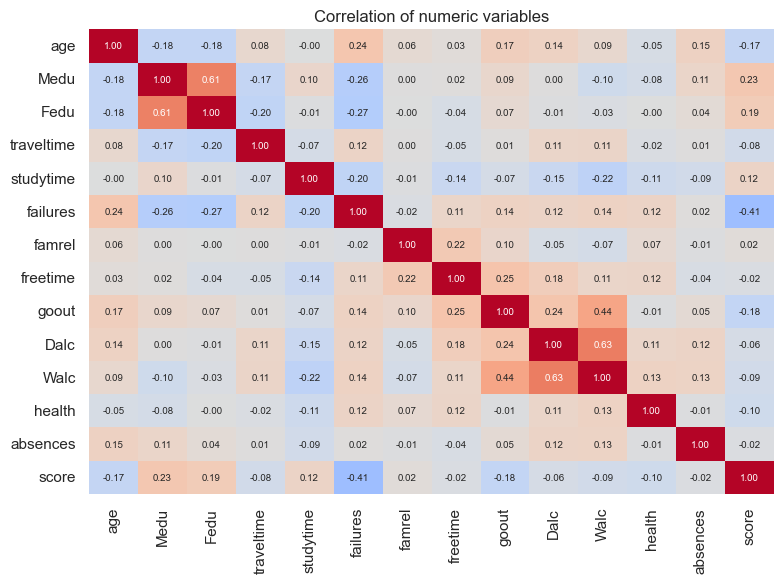

In [94]:
plt.figure(figsize=(8, 6))
sns.heatmap(train[num_cols + ["score"]].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws=dict(size=7), cbar=False)
plt.title("Correlation of numeric variables")
plt.tight_layout(); plt.show()

## 1.6 EDA conclusion
* Relations are mostly **weak and roughly linear**. The strongest single signals are `failures` (clearly negative), `Medu`/`Fedu` and `Mjob` (positive), `goout` (negative), plus `higher`, `schoolsup`, `age` (read off the plots and the table above).
* `absences` is **heavily right-skewed** (many zeros, a few very large values) and shows no clear linear pattern, so it needs a transformation.
* `failures` is mostly 0 with a few large values, which suggests a **threshold effect** (any failure vs none).
* Predictors are ordinal (1 to 5) with few levels. Linear trends are plausible but not guaranteed, so non-linear models are worth testing.
* Because the signal is weak, **expect a modest R²**. The main risk is over-fitting, which favours regularised or heavily averaged models.

---
# 2. Data preprocessing

The EDA showed a weak signal, a few skewed or threshold-like predictors, and ordinal variables with few levels. Before fitting any model we therefore decide how the raw columns are turned into model input. We set two rules up front:

1. **No leakage.** Every transformation lives *inside* the model pipeline, so it is re-fitted on the training part of each cross-validation fold only. Otherwise, for example, the scaling mean would be computed with validation rows and the CV error would look better than it is.
2. **Every feature needs a stated reason.** We only add a feature when the EDA gives a concrete argument for it, and we check afterwards what it costs (collinearity, Section 2.3).

## 2.1 The skewed predictor: `absences`

`absences` is the one raw predictor we transform first, for three reasons that all come from Section 1:

* **Extreme skew.** Most students have few absences, but a handful have very large counts. In linear and distance-based models these few rows have high leverage: they pull the coefficients and dominate Euclidean distances (KNN), and standardising does not remove the long tail.
* **No linear pattern.** The LOWESS plot in 1.2 shows no straight-line relation with `score`, so entering `absences` as-is would give the linear models a misspecified effect.
* **A spike at zero.** Many students have exactly 0 absences. Zero is qualitatively different from "a few", and one smooth curve cannot describe both groups.

We therefore use `log1p(absences)` (the log of 1 + x, which is defined at zero) to compress the tail and add a separate `no_absences` flag for the zero group. Tree-based models do not need this (they split on thresholds and ignore monotone transformations), but giving every model the same inputs keeps the comparison between frameworks fair. The figure compares the raw variable, the transformed variable and its relation to the score.

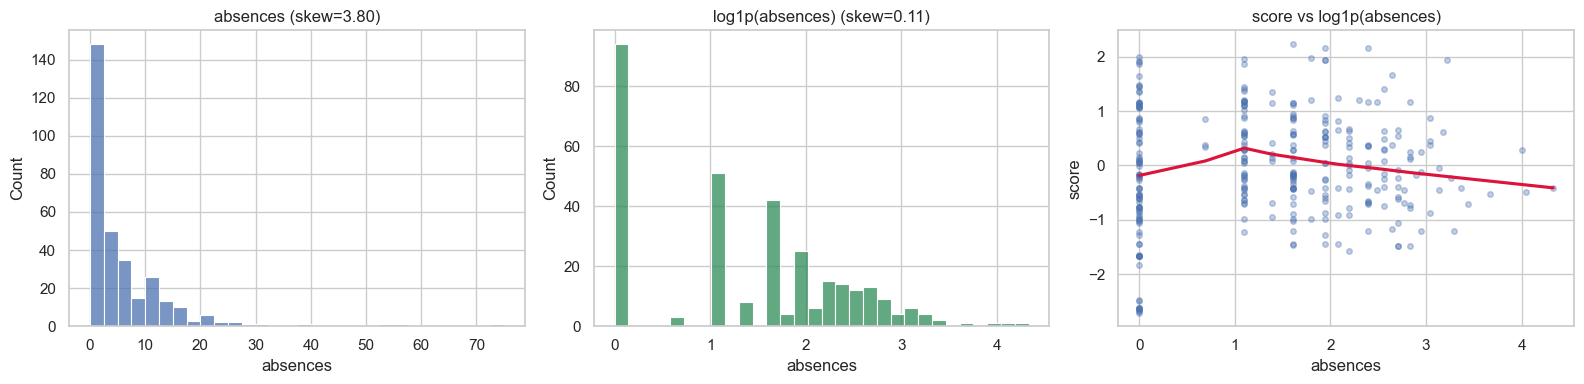

In [95]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(train["absences"], bins=30, ax=ax[0]); ax[0].set_title(f"absences (skew={stats.skew(train['absences']):.2f})")
la = np.log1p(train["absences"])
sns.histplot(la, bins=30, ax=ax[1], color="seagreen"); ax[1].set_title(f"log1p(absences) (skew={stats.skew(la):.2f})")
sns.regplot(x=la, y=train["score"], lowess=True, scatter_kws=dict(alpha=.35, s=16), line_kws=dict(color="crimson"), ax=ax[2])
ax[2].set_title("score vs log1p(absences)")
plt.tight_layout(); plt.show()

The transformation does what we wanted: the skew drops from 3.80 to 0.11. The right panel also shows why the zero flag is worth having. The 30 % of students with no absences (0 on the log axis) score *lower* on average (LOWESS at about −0.2) than students with one or a few absences (about +0.3), and from there the score declines steadily as absences grow. A single straight line through `log1p(absences)` would miss this kink, so the `no_absences` flag gives the zero group its own level while `log_absences` describes the decline.

## 2.2 Engineered features

Beyond `absences`, we add three more features. Each one has a reason we can state in a sentence:

| Feature | Definition | Why we add it |
|---|---|---|
| `log_absences`, `no_absences` | `log1p(absences)`; 1 if `absences == 0` | tames the skew and separates "never absent" from the rest (Section 2.1) |
| `had_failure` | `failures > 0` | `failures` is almost always 0; what seems to matter is whether a student has failed *at all*, which a single 0/1 column expresses directly |
| `Medu_plus_Fedu` | `Medu + Fedu` | one "household education" score. Both parents' education relate positively to `score` and to each other, so their sum is a steadier signal than either alone |
| `alc_total` | `Dalc + Walc` | weekday and weekend drinking move together, so their sum is one overall measure of alcohol use |

Raw `absences` is dropped after the transformation. All other raw columns are kept, so the general models can decide for themselves whether an engineered column adds anything beyond its parents.

In [96]:
def engineer(df):
    d = df.copy()
    d["log_absences"] = np.log1p(d["absences"])
    d["no_absences"] = (d["absences"] == 0).astype(float)
    d["had_failure"] = (d["failures"] > 0).astype(float)
    d["Medu_plus_Fedu"] = d["Medu"] + d["Fedu"]
    d["alc_total"] = d["Dalc"] + d["Walc"]
    return d.drop(columns="absences")

X_eng = engineer(X_raw)
print(f"corr(Medu, Fedu) = {X_raw['Medu'].corr(X_raw['Fedu']):.2f} | corr(Dalc, Walc) = {X_raw['Dalc'].corr(X_raw['Walc']):.2f}")
X_eng.assign(score=y)[["log_absences", "no_absences", "had_failure", "Medu_plus_Fedu", "alc_total", "score"]].describe().round(2)

corr(Medu, Fedu) = 0.61 | corr(Dalc, Walc) = 0.63


,log_absences,no_absences,had_failure,Medu_plus_Fedu,alc_total,score
count,316.00,316.00,316.00,316.00,316.00,316.00
mean,1.36,0.30,0.23,5.24,3.76,-0.02
std,1.06,0.46,0.42,1.98,1.96,0.99
min,0.00,0.00,0.00,1.00,2.00,-2.71
25%,0.00,0.00,0.00,4.00,2.00,-0.63
50%,1.61,0.00,0.00,5.00,3.00,-0.03
75%,2.20,1.00,0.00,7.00,5.00,0.64
max,4.33,1.00,1.00,8.00,10.00,2.23


## 2.3 A side effect: multicollinearity

The two sums are exact linear combinations of their parents, so they are perfectly collinear with them, and the other derived columns are strongly related to theirs. This is harmless for penalised and tree-based models, but it matters for plain OLS, where collinear columns make coefficients unstable. One of our candidates, the hierarchical regression (Part 3.2), is built entirely from OLS, so we measured the problem *before* fixing its feature sets.

We use the **variance inflation factor** `VIF_j = 1 / (1 - R²_j)`, where `R²_j` comes from regressing column `j` on all other numeric columns. A common rule of thumb flags VIF above 5. The left panel uses all numeric columns (parents and derived); the right panel lets each derived sum *replace* its parents.

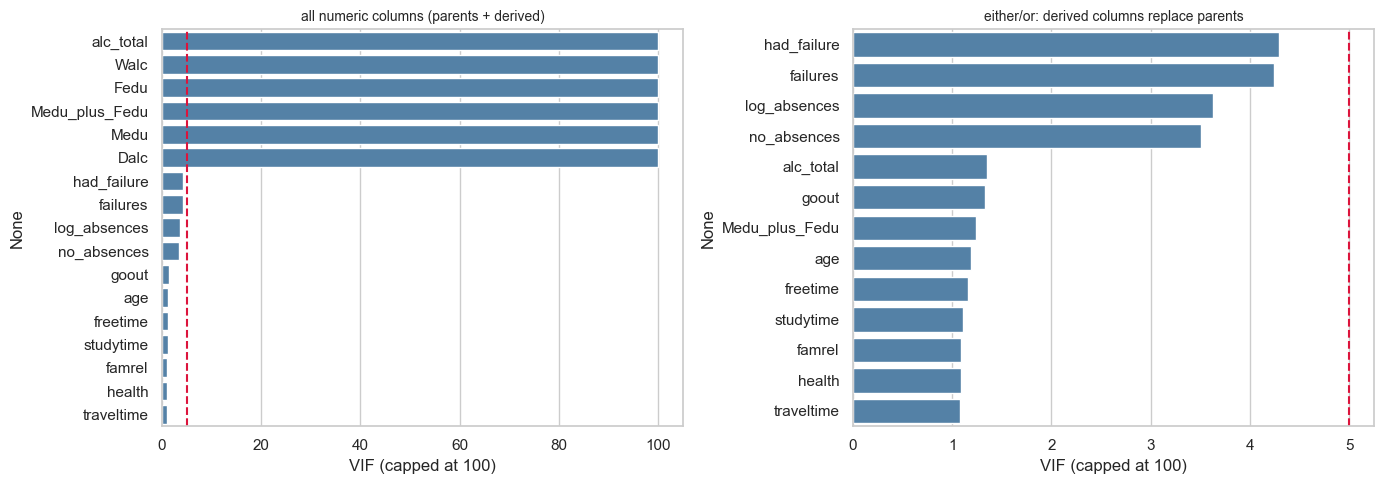

max VIF, parents + derived: 1000000.0 | max VIF, either/or: 4.3


In [97]:
def vif_table(df):
    out = {}
    for c in df.columns:
        r2 = LinearRegression().fit(df.drop(columns=c), df[c]).score(df.drop(columns=c), df[c])
        out[c] = np.inf if r2 > 1 - 1e-10 else 1 / (1 - r2)
    return pd.Series(out, name="VIF").sort_values(ascending=False)

num_eng = X_eng.select_dtypes("number")
num_either_or = num_eng.drop(columns=["Medu", "Fedu", "Dalc", "Walc"])      # keep the derived feature, drop its parents

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for a, (lab, d) in zip(ax, [("all numeric columns (parents + derived)", num_eng),
                            ("either/or: derived columns replace parents", num_either_or)]):
    v = vif_table(d).clip(upper=100)
    sns.barplot(x=v.values, y=v.index, color="steelblue", ax=a); a.axvline(5, color="crimson", ls="--")
    a.set_title(lab, fontsize=10); a.set_xlabel("VIF (capped at 100)")
plt.tight_layout(); plt.show()
print("max VIF, parents + derived:", round(vif_table(num_eng).replace(np.inf, 1e6).max(), 1),
      "| max VIF, either/or:", round(vif_table(num_either_or).max(), 1))

**What the figure shows.** With parents and derived columns together, the VIF of `alc_total`, `Dalc`, `Walc`, `Medu_plus_Fedu`, `Medu` and `Fedu` is infinite (exact linear dependence). When each sum *replaces* its parents, the largest VIF is 4.3 (`failures` and `had_failure`) and every other column is below 4. We keep both failure columns because 4.3 is still under the threshold and `had_failure` carries the threshold effect.

**Decision.** Keeping a sum *and* its parents creates exact collinearity, so we treat each pair as an **either/or choice**:

* the penalised and tree-based models receive all columns, because the penalty or the tree splitting copes with redundancy;
* the OLS-based **hierarchical model** (Part 3.2) receives one side of each pair, and we test all four combinations in Part 4.

It is worth seeing what the sum does inside a linear model: it forces the mother's and father's education to share one coefficient (one parameter instead of two). Whether that restriction helps or hurts is an empirical question that we answer in 4.3.

## 2.4 Encoding and scaling

Models need numeric input, and two of them (Ridge/Lasso and KNN) are sensitive to the scale of each column. We therefore finish the pipeline with two steps:

| Step | Why |
|---|---|
| One-hot encoding (binary variables get 1 dummy, variables with 3+ levels one column per level; unseen levels in new data are ignored) | numeric input for the models without imposing an artificial order on categories such as `Mjob` |
| Standardisation of every column | gives every column the same weight under the Ridge/Lasso penalty and in KNN distances |

Both steps are bundled with the feature engineering in one pipeline, which is what guarantees that nothing is fitted outside the training folds.

In [98]:
def make_pre(fe=engineer):
    return Pipeline([
        ("fe", FunctionTransformer(fe)),
        ("ct", ColumnTransformer(
            [("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False),
              make_column_selector(dtype_include=["category", "object"]))],
            remainder="passthrough", verbose_feature_names_out=False)),
        ("sc", StandardScaler()),
    ])

pre_demo = make_pre().fit(X_raw)
feat_names = pre_demo.named_steps["ct"].get_feature_names_out()
print(len(feat_names), "model features after encoding:")
print(list(feat_names))

47 model features after encoding:
['school_MS', 'sex_M', 'address_U', 'famsize_LE3', 'Pstatus_T', 'Mjob_at_home', 'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_at_home', 'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher', 'reason_course', 'reason_home', 'reason_other', 'reason_reputation', 'guardian_father', 'guardian_mother', 'guardian_other', 'schoolsup_yes', 'famsup_yes', 'paid_yes', 'activities_yes', 'nursery_yes', 'higher_yes', 'internet_yes', 'romantic_yes', 'age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'log_absences', 'no_absences', 'had_failure', 'Medu_plus_Fedu', 'alc_total']


**Result.** The 34 columns that remain after feature engineering (30 raw, minus `absences`, plus five engineered) expand to 47 standardised model inputs. The hierarchical model works on the engineered data frame before encoding and uses the either/or column lists. From here on every model simply receives the raw data frame, and its pipeline performs all of the steps above inside each CV fold.

---
# 3. Theoretical framework of the models

With the model inputs fixed, we introduce the models we compare. This part only describes them; all fitting happens in Part 4. The candidates span four frameworks, from very rigid to very flexible, so that the comparison shows how much flexibility this data can support.

## 3.0 Two ideas that run through everything

**Bias-variance trade-off.** The expected test error of a model splits into `bias² + variance + irreducible noise`. Rigid models (high bias) miss structure; flexible models (high variance) fit noise. With only 316 rows and weak signal, variance is the main enemy, so tuning is about choosing the *right amount of flexibility*.

**Hyper-parameters and nested cross-validation.** Hyper-parameters (penalty strength, `k`, tree depth, ...) are not learned by fitting and must be chosen by validation. If the same folds both choose and evaluate them, the reported error is optimistic. **Nested CV** fixes this: an *inner* CV loop picks the hyper-parameters, an *outer* loop scores the whole procedure on data never used for tuning.

## 3.1 Baseline and linear framework

| Model | Idea | Hyper-parameters |
|---|---|---|
| **Mean baseline** | predict the training mean for everyone | none |
| **OLS** | $\hat y = \beta_0 + \sum_j \beta_j x_j$, with $\beta$ minimising $\sum_i (y_i-\hat y_i)^2$. Unbiased but high-variance when predictors are many or correlated | none |
| **Ridge** | OLS + $\alpha\sum_j\beta_j^2$ (L2 penalty). Shrinks all coefficients smoothly and handles collinearity | $\alpha$ |
| **Lasso** | OLS + $\alpha\sum_j\lvert\beta_j\rvert$ (L1 penalty). Shrinks and sets some coefficients exactly to zero (variable selection) | $\alpha$ |
| **Elastic Net** | mix of both penalties, $\alpha[\rho\lVert\beta\rVert_1 + (1-\rho)\lVert\beta\rVert_2^2/2]$ | $\alpha$, $\rho$ (`l1_ratio`) |

## 3.2 Hierarchical (theme-based) regression

A linear model with built-in structure. Predictors are grouped into three themes (**academic**, **family**, **lifestyle**). Stage 1 fits one OLS per theme and keeps its fitted values as a one-number summary (*proxy*) of that theme. Stage 2 fits a master OLS of `score` on the three proxies. This reduces the number of coefficients the final stage must estimate, and makes the result interpretable at theme level. It has no hyper-parameters; the design choice is which columns go in which theme (Part 4).

## 3.3 Instance-based framework

| Model | Idea | Hyper-parameters |
|---|---|---|
| **K-nearest neighbours** | predict the average `score` of the $k$ most similar students (Euclidean distance on standardised features); optionally weight neighbours by inverse distance | $k$, weighting |

No model is fitted. It suffers from the curse of dimensionality: with about 47 features after encoding, "nearest" neighbours are often not very near.

## 3.4 Tree-based framework

| Model | Idea | Hyper-parameters |
|---|---|---|
| **Regression tree** | recursively split the data on the feature/threshold that most reduces squared error; predict the leaf mean. Captures interactions and non-linearity, but a single deep tree is very unstable | `max_depth`, `min_samples_leaf` |
| **Random forest** | average many trees, each grown on a bootstrap sample and using a random subset of features per split. Averaging decorrelated trees cuts variance without raising bias much | `max_features`, `min_samples_leaf` |
| **Gradient boosting** | build shallow trees *sequentially*, each one fitting the residual errors of the ensemble so far, scaled by a learning rate. Reduces bias; needs regularisation (small learning rate, shallow trees, subsampling) | `learning_rate`, `max_depth`, `n_estimators` |

## 3.5 How the frameworks compare

| Framework | Flexibility | Main risk | Expected fit for this data |
|---|---|---|---|
| Baseline | none | under-fitting | reference only |
| Linear (OLS) | low | variance from many correlated predictors | mediocre |
| Linear, penalised | low to medium | bias if over-shrunk | good when signal is weak |
| Hierarchical | low, structured | bias from the theme split | competitive, interpretable |
| KNN | medium | curse of dimensionality | poor with about 47 features after encoding |
| Single tree | medium to high | instability | poor unless pruned hard |
| Forest / boosting | high, but averaged | over-fitting (boosting), cost | strongest candidates |

---
# 4. Model tuning and comparison

With the features fixed and the model families introduced, we ask two questions: which settings work best *within* each framework, and which framework works best *across* the board. The plan:

1. **Set up** the estimators, tuning grids and the CV scheme (4.0).
2. **Run nested CV** for every model, which tunes and evaluates in a single pass (4.1).
3. **Visualise the tuning** that happened inside that run (4.2).
4. **Compare within** each framework (4.3), then **across** frameworks (4.4).

## 4.0 Set-up

### The hierarchical estimator
scikit-learn has no hierarchical regression, so we wrote a small custom estimator that follows the three stages of Part 3.2. The column lists below define the three themes. Each variant contains only one side of every collinear pair (Part 2.3), and we test all four combinations later.

In [99]:
class HierarchicalRegressor(RegressorMixin, BaseEstimator):
    # Academic / family / lifestyle sub-models -> proxies -> master OLS.

    def __init__(self, academic_cols, family_cols, lifestyle_cols):
        self.academic_cols = academic_cols
        self.family_cols = family_cols
        self.lifestyle_cols = lifestyle_cols

    def _block_pipe(self, cols, X):
        cat = [c for c in cols if not pd.api.types.is_numeric_dtype(X[c])]
        ct = ColumnTransformer(
            [("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False), cat)],
            remainder="passthrough")
        return Pipeline([("ct", ct), ("lm", LinearRegression())])

    def fit(self, X, y):
        X = pd.DataFrame(X).reset_index(drop=True); y = np.asarray(y)
        self.blocks_ = {"academic": self.academic_cols, "family": self.family_cols, "lifestyle": self.lifestyle_cols}
        self.sub_pipes_ = {k: self._block_pipe(c, X).fit(X[c], y) for k, c in self.blocks_.items()}   # stage 1
        self.master_ = LinearRegression().fit(self._proxies(X), y)                                      # stage 2
        return self

    def _proxies(self, X):
        return np.column_stack([self.sub_pipes_[k].predict(X[c]) for k, c in self.blocks_.items()])

    def predict(self, X):
        X = pd.DataFrame(X).reset_index(drop=True)
        return self.master_.predict(self._proxies(X))


def hier_blocks(parent_edu="separate", alcohol="separate"):
    # Column lists for the three themes. Never includes both a derived sum and its parents (see 2.3).
    academic = ["school", "reason", "studytime", "failures", "had_failure",
                "schoolsup", "paid", "higher", "log_absences", "no_absences", "traveltime"]
    family = (["Medu", "Fedu"] if parent_edu == "separate" else ["Medu_plus_Fedu"]) + \
             ["guardian", "Mjob", "Fjob", "famsize", "Pstatus", "famrel", "nursery", "famsup"]
    lifestyle = ["age", "sex", "address", "health", "romantic", "activities", "internet", "freetime", "goout"] + \
                (["Dalc", "Walc"] if alcohol == "separate" else ["alc_total"])
    return academic, family, lifestyle

HIER_VARIANTS = {   # 2 x 2 design: parents vs derived sum, for each pair
    "Hier. A (Medu, Fedu / Dalc, Walc)":     dict(parent_edu="separate", alcohol="separate"),
    "Hier. B (Medu_plus_Fedu / Dalc, Walc)": dict(parent_edu="sum",      alcohol="separate"),
    "Hier. C (Medu, Fedu / alc_total)":      dict(parent_edu="separate", alcohol="total"),
    "Hier. D (Medu_plus_Fedu / alc_total)":  dict(parent_edu="sum",      alcohol="total"),
}

### Model registry, tuning grids and CV scheme

All candidates live in one registry together with their tuning grids, so every model is tuned and scored by exactly the same code.

* Grids are wide enough to contain both the over-fitting end (weak penalty, deep trees, few neighbours) and the over-shrunk end, so that the optimum can be seen inside the range. The forest and boosting grids were widened after a first, narrower run placed their best settings at the edge.
* `FRAMEWORK` tags each model with its family for the within-framework comparison.
* `inner_cv` (5-fold) chooses hyper-parameters; `outer_cv` (5-fold × 3 repeats = 15 test folds) scores the whole procedure. All models share the same outer folds, so differences between models are **paired**.
* The random seed is fixed (`SEED = 35`) so that all results are reproducible.

In [100]:
def pipe(model, fe=engineer):
    if isinstance(model, HierarchicalRegressor):
        return Pipeline([("fe", FunctionTransformer(fe)), ("m", model)])       # OLS blocks: no scaling needed
    return Pipeline([("pre", make_pre(fe)), ("m", model)])

BASE = "Mean (baseline)"
MODELS = {
    BASE: (DummyRegressor(), {}),
    "OLS": (LinearRegression(), {}),
    "Ridge": (Ridge(), {"m__alpha": np.logspace(-1, 3, 30)}),
    "Lasso": (Lasso(max_iter=50000), {"m__alpha": np.logspace(-3, -0.3, 30)}),
    "Elastic Net": (ElasticNet(max_iter=50000), {"m__alpha": np.logspace(-3, -0.3, 15), "m__l1_ratio": [.2, .5, .8]}),
    **{name: (HierarchicalRegressor(*hier_blocks(**flags)), {}) for name, flags in HIER_VARIANTS.items()},
    "KNN": (KNeighborsRegressor(), {"m__n_neighbors": [5, 10, 15, 20, 30, 40, 60], "m__weights": ["uniform", "distance"]}),
    "Tree": (DecisionTreeRegressor(random_state=SEED), {"m__max_depth": [2, 3, 4, 5], "m__min_samples_leaf": [5, 10, 20]}),
    "Random Forest": (RandomForestRegressor(n_estimators=300, random_state=SEED),
                      {"m__max_features": [0.2, 0.4], "m__min_samples_leaf": [3, 8]}),
    "Gradient Boosting": (GradientBoostingRegressor(subsample=0.7, random_state=SEED),
                          {"m__learning_rate": [0.005, 0.01, 0.03], "m__max_depth": [1, 2, 3], "m__n_estimators": [200, 300, 400]}),
}
FRAMEWORK = {BASE: "Baseline", "OLS": "Linear", "Ridge": "Linear", "Lasso": "Linear", "Elastic Net": "Linear",
             **{k: "Hierarchical" for k in HIER_VARIANTS},
             "KNN": "Instance-based", "Tree": "Tree-based", "Random Forest": "Tree-based", "Gradient Boosting": "Tree-based"}

inner_cv = KFold(5, shuffle=True, random_state=SEED)
outer_cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=SEED)

def tuned(name, fe=engineer, cv=inner_cv):
    model, grid = MODELS[name]
    return GridSearchCV(pipe(model, fe), grid, cv=cv, scoring="neg_mean_squared_error", n_jobs=1)

## 4.1 Nested cross-validation for every model

For each model, the inner 5-fold CV tunes the hyper-parameters by grid search and the outer 5 × 3 repeated CV scores the whole procedure on rows never used for tuning. We also keep the training-fold error to measure over-fitting (`overfit_ratio = CV MSE / train MSE`; 1 = no over-fitting). With `return_estimator=True` we additionally keep every fitted grid search: each one holds the full tuning record that we visualise in 4.2, so no grid has to be run twice.

In [101]:
t0 = time.time()
nested = {}
for name in MODELS:
    nested[name] = cross_validate(tuned(name), X_raw, y, cv=outer_cv, n_jobs=-1, return_train_score=True, return_estimator=True,
                                  scoring={"mse": "neg_mean_squared_error", "r2": "r2"})
    print(f"{name:34s} done ({time.time() - t0:5.0f}s)  CV MSE = {-nested[name]['test_mse'].mean():.4f}")

rows = []
for name, r in nested.items():
    cv_mse, tr_mse = -r["test_mse"].mean(), -r["train_mse"].mean()
    rows.append(dict(model=name, framework=FRAMEWORK[name], CV_MSE=cv_mse, train_MSE=tr_mse,
                     fold_sd_MSE=(-r["test_mse"]).std(), overfit_ratio=cv_mse / tr_mse))
res = pd.DataFrame(rows).set_index("model")

Mean (baseline)                    done (   10s)  CV MSE = 0.9746
OLS                                done (   12s)  CV MSE = 0.8467
Ridge                              done (   37s)  CV MSE = 0.7855
Lasso                              done (   58s)  CV MSE = 0.7848
Elastic Net                        done (   93s)  CV MSE = 0.7851
Hier. A (Medu, Fedu / Dalc, Walc)  done (   95s)  CV MSE = 0.8001
Hier. B (Medu_plus_Fedu / Dalc, Walc) done (   96s)  CV MSE = 0.7971
Hier. C (Medu, Fedu / alc_total)   done (   98s)  CV MSE = 0.7976
Hier. D (Medu_plus_Fedu / alc_total) done (   99s)  CV MSE = 0.7946
KNN                                done (  107s)  CV MSE = 0.8644
Tree                               done (  115s)  CV MSE = 0.8007
Random Forest                      done (  136s)  CV MSE = 0.7525
Gradient Boosting                  done (  216s)  CV MSE = 0.7689


For hierarchical variants, Hier. D works the best. This will be renamed as Hier MAIN for the rest of the notebook.

In [102]:
HIER_MAIN = "Hier. D (Medu_plus_Fedu / alc_total)"

## 4.2 How the tuning behaved

Every grid search inside 4.1 recorded the inner-CV error of each candidate setting. We average these errors over the 15 outer folds (each fold's search saw a different 80 % of the data) and plot them: a line for one hyper-parameter, a heatmap for two or more. The dashed line is the mean-baseline error, and a good grid has its optimum **inside** the range rather than on its edge. The table underneath shows which setting the 15 outer folds actually picked.

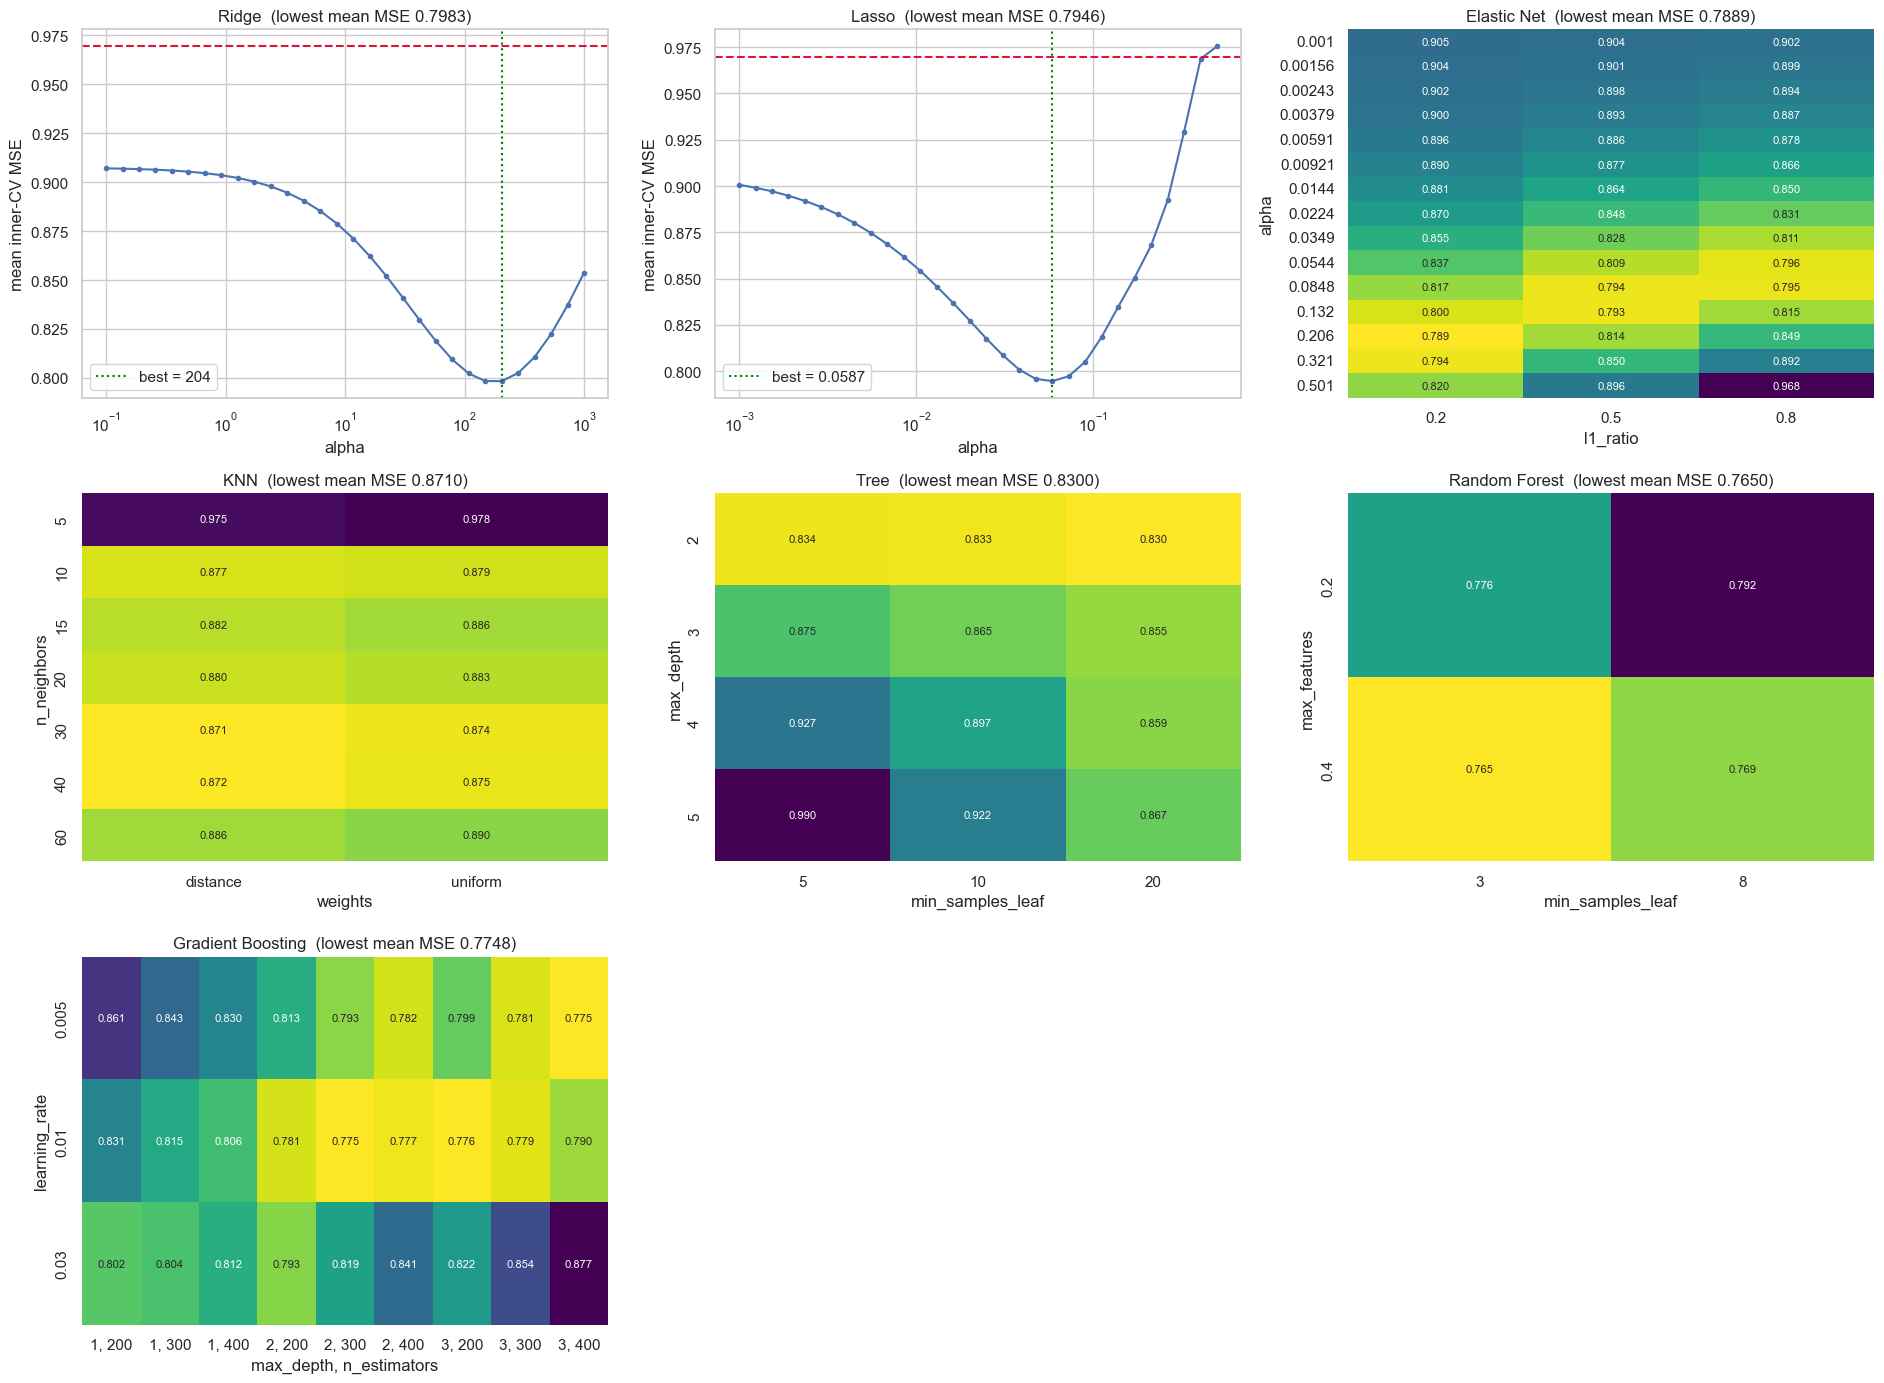

,most_chosen_setting,picked_in_folds
Ridge,{'alpha': np.float64(148.7352)},6/15
Lasso,{'alpha': np.float64(0.0587)},8/15
Elastic Net,"{'alpha': np.float64(0.2062), 'l1_ratio': 0.2}",8/15
KNN,"{'n_neighbors': 10, 'weights': 'distance'}",4/15
Tree,"{'max_depth': 2, 'min_samples_leaf': 20}",6/15
Random Forest,"{'max_features': 0.4, 'min_samples_leaf': 3}",10/15
Gradient Boosting,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est...",5/15


In [103]:
from collections import Counter

def tuning_record(name):
    ests = nested[name]["estimator"]
    r = pd.DataFrame(ests[0].cv_results_["params"])
    r.columns = [c.replace("m__", "") for c in r.columns]
    r["mse"] = np.mean([-e.cv_results_["mean_test_score"] for e in ests], axis=0)   # average over the 15 outer folds
    return r, ests

def plot_tuning(name, ax, logx=False):
    r, _ = tuning_record(name)
    params = [c for c in r.columns if c != "mse"]
    if len(params) == 1:
        ax.plot(r[params[0]], r["mse"], marker="o", ms=3)
        if logx: ax.set_xscale("log")
        best = r.loc[r["mse"].idxmin(), params[0]]
        ax.axvline(best, color="green", ls=":", label=f"best = {best:.3g}")
        ax.axhline(y.var(), color="crimson", ls="--"); ax.set_xlabel(params[0]); ax.set_ylabel("mean inner-CV MSE"); ax.legend()
    else:
        cols = params[1:]
        r = r.sort_values(cols)
        r["_col"] = r[cols].astype(str).agg(", ".join, axis=1)
        piv = r.pivot_table(index=params[0], columns="_col", values="mse")[r["_col"].drop_duplicates()]
        piv.index = [f"{v:.3g}" if isinstance(v, float) else v for v in piv.index]
        sns.heatmap(piv, annot=True, fmt=".3f", cmap="viridis_r", cbar=False, ax=ax, annot_kws=dict(size=8))
        ax.set_ylabel(params[0]); ax.set_xlabel(", ".join(cols))
    ax.set_title(f"{name}  (lowest mean MSE {r['mse'].min():.4f})")

tuned_names = ["Ridge", "Lasso", "Elastic Net", "KNN", "Tree", "Random Forest", "Gradient Boosting"]
fig, axes = plt.subplots(3, 3, figsize=(19, 14)); axes = axes.ravel()
for ax, name in zip(axes, tuned_names):
    plot_tuning(name, ax, logx=name in ("Ridge", "Lasso"))
for ax in axes[len(tuned_names):]: ax.axis("off")
plt.tight_layout(); plt.show()

chosen = {}
for name in tuned_names:
    top, cnt = Counter(str({k.replace("m__", ""): (round(v, 4) if isinstance(v, float) else v)
                            for k, v in e.best_params_.items()}) for e in nested[name]["estimator"]).most_common(1)[0]
    chosen[name] = dict(most_chosen_setting=top, picked_in_folds=f"{cnt}/15")
pd.DataFrame(chosen).T

**Reading the figure.**

* **Ridge / Lasso:** both curves are U-shaped. At a weak penalty the error (about 0.88) is close to that of unpenalised OLS; it is lowest at $\alpha\approx 150$ (Ridge) and $\alpha\approx 0.05$ (Lasso), and climbs back towards the baseline once everything is shrunk away. This is the bias-variance trade-off made visible. Ridge needs such a heavy penalty because most of the dummy columns are noise.
* **Elastic Net:** the near-best cells lie along a diagonal (a larger `l1_ratio` needs a smaller $\alpha$). The best mix (0.782 at $\alpha\approx 0.2$, `l1_ratio` 0.2) is only marginally better than either pure penalty (0.788).
* **KNN:** $k=5$ is far too noisy (0.96, almost the baseline); for $k$ between 10 and 40 the error is flat at about 0.87, and it rises again at $k=60$. Distance weighting helps marginally. Even at its best KNN stays far above the penalised linear models.
* **Tree:** the best tree is the shallowest one we allowed (depth 2, 5 rows per leaf, 0.81), and the error grows with depth (0.96 at depth 5 with small leaves) because deep trees fit noise. The optimum sits on the lower edge of the depth grid, which tells us that a single tree is useful mainly as a weak reference.
* **Random forest:** the surface is very flat (0.758 to 0.787). The best cell (`max_features` 0.4, `min_samples_leaf` 5) is at the upper edge for `max_features`, but moving from 0.3 to 0.4 changes the error by only 0.002, so a wider grid would not change the conclusion.
* **Gradient boosting:** a slower learning rate needs more trees: 0.01 with 300 trees and 0.005 with 400 trees reach the same error (0.766), while a learning rate of 0.03 over-fits quickly as trees get deeper or more numerous (up to 0.876).

The table confirms how flat these optima are. The most frequently chosen setting was picked in only 3 to 8 of the 15 outer folds, because neighbouring settings are nearly tied. The final model is therefore not sensitive to the exact hyper-parameters. The lowest mean errors here are slightly below the nested-CV errors of the next section (forest 0.7575 vs 0.7612), which is the small optimism of selecting the best setting on the folds that score it; this is why the comparison uses the outer folds.

## 4.3 Comparison **within** each framework

With the tuning understood, we ask whether extra flexibility or structure pays off *inside* each family.

In [104]:
cols = ["CV_MSE", "fold_sd_MSE", "CV_R2", "train_MSE", "overfit_ratio"]
for fw in ["Linear", "Hierarchical", "Tree-based"]:
    print(f"\n=== {fw} ===")
    display(res[res["framework"] == fw].sort_values("CV_MSE")[cols].round(4))


=== Linear ===


KeyError: "['CV_R2'] not in index"

**Interpretation.**

* **Linear:** penalisation clearly beats plain OLS (0.789 to 0.793 vs 0.861). Ridge, Lasso and Elastic Net are practically indistinguishable, and OLS pays a variance cost for the many dummy columns (overfit ratio 1.45).
* **Hierarchical:** the four variants differ by under 0.01 in MSE, which is small next to the fold-to-fold SD of about 0.12. The ordering is consistent (each sum is slightly better than its separate parents, variant D is the lowest), but we do not treat this as evidence that one feature choice is better. We use variant D because we fixed it in advance as the collinearity-free, most compact option (Part 2.3), and it happens to also have the lowest error.
* **Tree-based:** averaging (forest, 0.761) and sequential correction (boosting, 0.786) both improve massively on the single tree (0.865, worse even than OLS and with the largest fold SD, 0.20, i.e. very unstable). The forest also over-fits the training folds most (overfit ratio 2.0) yet generalises best, so in-sample fit is not a good guide to test error.

## 4.4 Comparison **across** frameworks

Next we put the families side by side. One representative per model enters: hierarchical variant D, chosen a priori rather than by CV score, so it carries no selection bias.

,framework,CV_MSE,fold_sd_MSE,CV_R2,train_MSE,overfit_ratio
model,,,,,,
Random Forest,Tree-based,0.7525,0.1607,0.2199,0.3525,2.1349
Gradient Boosting,Tree-based,0.7689,0.1631,0.2026,0.5202,1.4780
Lasso,Linear,0.7848,0.1496,0.1832,0.6745,1.1634
Elastic Net,Linear,0.7851,0.1526,0.1834,0.6728,1.1668
Ridge,Linear,0.7855,0.1525,0.1824,0.6493,1.2097
Hierarchical,Hierarchical,0.7946,0.1714,0.1753,0.6448,1.2322
Tree,Tree-based,0.8007,0.1657,0.1670,0.7122,1.1241
OLS,Linear,0.8467,0.1570,0.1149,0.5967,1.4189
KNN,Instance-based,0.8644,0.1574,0.1002,0.1874,4.6133


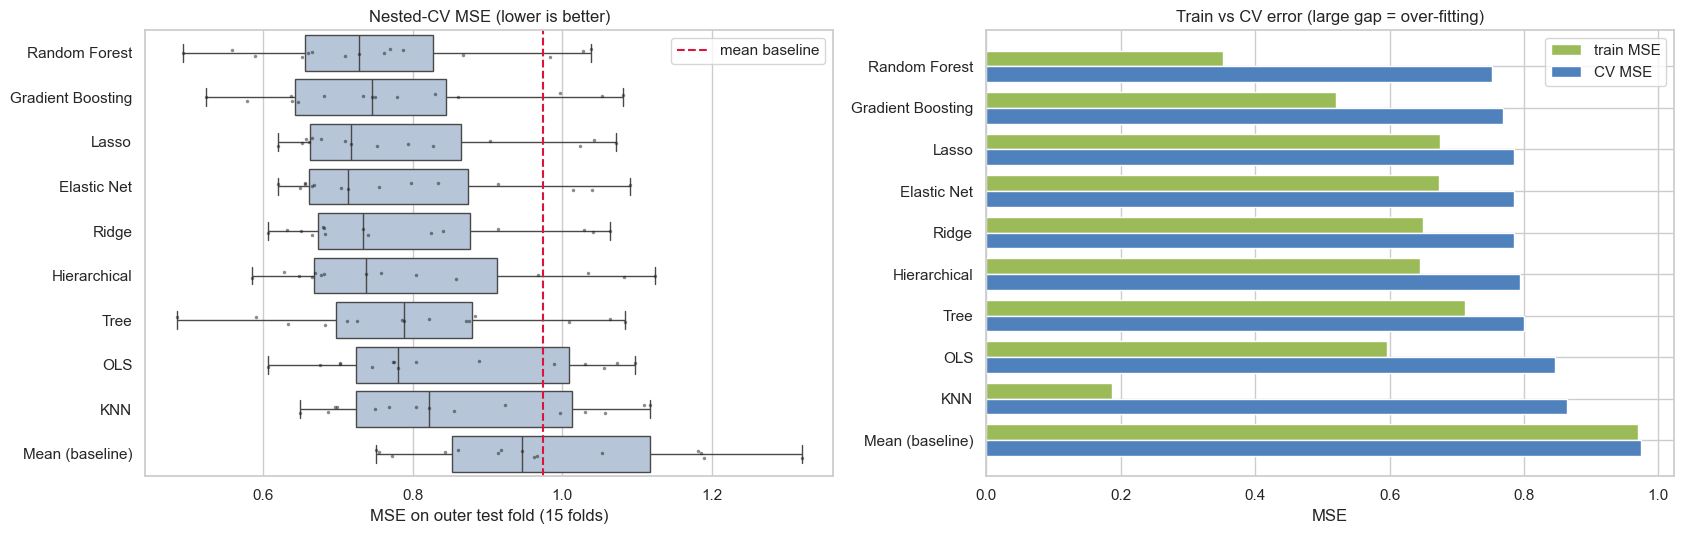

In [ ]:
across = res.drop(index=[k for k in HIER_VARIANTS if k != HIER_MAIN]).rename(index={HIER_MAIN: "Hierarchical"})
across = across.sort_values("CV_MSE")
order = across.index.tolist()
display(across[["framework"] + cols].round(4))

fold_mse = pd.DataFrame({("Hierarchical" if k == HIER_MAIN else k): -nested[k]["test_mse"]
                         for k in across.index.map(lambda m: HIER_MAIN if m == "Hierarchical" else m)})[order]
fig, ax = plt.subplots(1, 2, figsize=(17, 5.5))
sns.boxplot(data=fold_mse, orient="h", ax=ax[0], color="lightsteelblue", fliersize=3)
sns.stripplot(data=fold_mse, orient="h", ax=ax[0], color="k", size=2.5, alpha=.5)
ax[0].axvline(across.loc[BASE, "CV_MSE"], color="crimson", ls="--", label="mean baseline")
ax[0].set_xlabel("MSE on outer test fold (15 folds)"); ax[0].set_title("Nested-CV MSE (lower is better)"); ax[0].legend()

w = 0.38; ypos = np.arange(len(order))
ax[1].barh(ypos - w/2, across["train_MSE"], w, label="train MSE", color="#9bbb59")
ax[1].barh(ypos + w/2, across["CV_MSE"], w, label="CV MSE", color="#4f81bd")
ax[1].set_yticks(ypos); ax[1].set_yticklabels(order); ax[1].invert_yaxis()
ax[1].set_xlabel("MSE"); ax[1].set_title("Train vs CV error (large gap = over-fitting)"); ax[1].legend()
plt.tight_layout(); plt.show()

### Are the top models really different?

Because all models share the same outer folds, we can compare them fold by fold against the best model: the mean difference in MSE, and the number of the 15 folds in which the best model has the lower error.

In [ ]:
best_name = across.index[0]
key = lambda m: HIER_MAIN if m == "Hierarchical" else m
diff_rows = []
for m in order[1:]:
    d = (-nested[key(m)]["test_mse"]) - (-nested[key(best_name)]["test_mse"])
    diff_rows.append(dict(model=m, mean_MSE_diff=d.mean(), folds_best_wins=f"{(d > 0).sum()}/{len(d)}"))
print(f"Best nested-CV model: {best_name}. Differences are (model - best):")
pd.DataFrame(diff_rows).set_index("model").round(4)

Best nested-CV model: Random Forest. Differences are (model - best):


,mean_MSE_diff,folds_best_wins
model,,
Gradient Boosting,0.0163,11/15
Lasso,0.0322,13/15
Elastic Net,0.0326,12/15
Ridge,0.0329,12/15
Hierarchical,0.0421,11/15
Tree,0.0481,11/15
OLS,0.0941,13/15
KNN,0.1119,14/15
Mean (baseline),0.2221,15/15


**Take-aways.**

1. Every model beats the mean baseline (0.979), but only modestly: the best CV R² is about 0.20. The signal in this data is weak.
2. **Plain OLS, the single tree and KNN** are the weakest real candidates: OLS and the tree suffer from variance, KNN from dimensionality (its training error of 0.09 against a CV error of 0.89 is a textbook case of over-fitting).
3. **Random forest** has the lowest error (0.761). Its advantage over gradient boosting, Ridge and Elastic Net is about 0.025 to 0.03 MSE, and it wins in 10 to 12 of the 15 folds. That is a consistent but modest margin compared with a fold SD of about 0.12, so the evidence favours the forest without making it a clear-cut winner.
4. The hierarchical model (0.803) gives up about 0.04 MSE against the forest in exchange for a theme-level interpretation and no tuning. We therefore carry the **random forest** into the final step.

# 5. Final model and predictions for `test.rds`

The model with the lowest nested-CV MSE is refit on **all** 316 training rows (with its hyper-parameters re-tuned by repeated CV) and used to predict the 79 test students.


Predictions:
 [ 0.49264072  0.04679934  0.38153014 -0.03758912 -0.05403317  0.82496343
  0.58474775  0.43554408  0.85943756  0.66352479 -0.1660994   0.20137908
  0.33181393 -0.41523047  0.234242    0.46768908  0.31847242 -0.40080716
  0.75565257 -0.05159461  0.5922357   0.3105034   0.22615093 -0.00344178
  0.26968099 -0.40739239  0.68264575  0.17362342 -0.55654033  0.53339733
  0.04878384  0.12607135  0.63624397  0.00814709 -0.53778916 -0.62282203
 -0.05747402  0.01045608  0.07944054  0.14387804  0.14009469  0.66753761
  0.01239532 -0.14415717 -0.48928467 -0.46845429 -0.38799432 -0.16618185
  0.37605715  0.35439056  0.41433333 -0.77566658  0.11616245  0.33935076
  0.71392823 -0.02996208  0.16903158  0.42173968  0.00230569 -0.25409627
 -0.32815882  0.09726766  0.52384203  0.07211253 -0.22173665  0.21438208
  0.46940291 -0.34490453 -0.17474337 -0.20648732 -0.08697067  0.00750221
 -0.07587526 -0.64764355  0.03331235  0.04867057  0.25856663  0.06878
  0.38484642]

Prediction summary: {'co

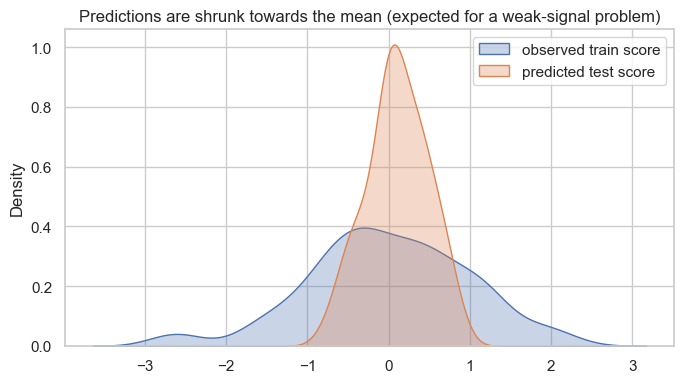

In [ ]:
final_cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=SEED)
final = tuned("Random Forest", cv=final_cv).fit(X_raw, y)

pred = final.predict(test)

print("\nPredictions:\n", pred)
print("\nPrediction summary:", pd.Series(pred).describe().round(3).to_dict())

fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(y, ax=ax, label="observed train score", fill=True, alpha=.3)
sns.kdeplot(pred, ax=ax, label="predicted test score", fill=True, alpha=.3)
ax.set_title("Predictions are shrunk towards the mean (expected for a weak-signal problem)"); ax.legend()
plt.tight_layout(); plt.show()

Save `predictions.rds` as a plain numeric vector (written with R's `saveRDS`, so `readRDS("predictions.rds")` returns a numeric vector of length 79).

In [ ]:
OUT_PATH = "predictions.rds"

assert len(pred) == len(test) == 79 and np.isfinite(pred).all()
if shutil.which("Rscript"):
    with tempfile.NamedTemporaryFile("w", suffix=".csv", delete=False) as f:
        pd.Series(pred).to_csv(f, index=False, header=False); tmp = f.name
    subprocess.run(["Rscript", "-e", f"x <- scan('{tmp}', quiet=TRUE); saveRDS(as.numeric(x), '{OUT_PATH}')"], check=True)
    os.remove(tmp)
else:
    pyreadr.write_rds(OUT_PATH, pd.DataFrame({"pred": pred}))   # fallback: data frame, not a bare vector

check = pyreadr.read_r(OUT_PATH)[None]
print("Saved", OUT_PATH, "| read back shape:", np.asarray(check).shape)

Saved predictions.rds | read back shape: (79, 1)
